# 05 - Grad-CAM Interpretability

This notebook loads the saved transfer-learning classifier and explains correct and incorrect predictions with Grad-CAM.

## Google Colab Git Setup

Run the next cell only when using Google Colab.

In [1]:
# Colab-only Git setup. Skip this cell when running locally.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/andri-10/computer_vision.git"

REPO_DIR = Path("/content/computer_vision")
PROJECT_DIR = REPO_DIR / "PetVision-DeepLearning"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    if REPO_DIR.exists():
        subprocess.check_call(["git", "-C", str(REPO_DIR), "pull", "origin", "main"])
    else:
        subprocess.check_call(["git", "clone", REPO_URL, str(REPO_DIR)])

    os.chdir(PROJECT_DIR)

    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"
    ])

    print("Colab repo root:", REPO_DIR)
    print("Colab project root:", os.getcwd())
else:
    print("Not running in Google Colab. Continue with the local setup cells below.")

Colab repo root: /content/computer_vision
Colab project root: /content/computer_vision/PetVision-DeepLearning


In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

for path in [
    "models",
    "results/classification",
    "results/segmentation",
    "results/gradcam",
    "results/figures",
]:
    (PROJECT_ROOT / path).mkdir(parents=True, exist_ok=True)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.data_loader import get_splits, load_label_mapping
from src.preprocessing import preprocess_transfer_classification
from src.gradcam import make_nested_backbone_gradcam_heatmap, top_k_predictions
from src.visualization import overlay_heatmap

In [4]:
MODEL_PATH = PROJECT_ROOT / "models/best_classifier.keras"
assert MODEL_PATH.exists(), "Run notebook 03 first to create models/best_classifier.keras"

classifier = tf.keras.models.load_model(MODEL_PATH)
label_mapping = load_label_mapping(PROJECT_ROOT / "results/figures/label_mapping.json")
label_names = [label_mapping[idx] for idx in sorted(label_mapping)]

_, _, test_raw, _, _ = get_splits()
prep = lambda example: preprocess_transfer_classification(example, backbone="mobilenet_v2")
test_ds = test_raw.map(prep, num_parallel_calls=tf.data.AUTOTUNE).batch(32).prefetch(tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.FWOJFW_4.0.0/oxford_iiit_pet-train.tfrecord-[0-…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.FWOJFW_4.0.0/oxford_iiit_pet-test.tfrecord-[0-9…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [5]:
# Collect a small pool of correct and incorrect predictions.
examples = []
for images, labels in test_ds.take(10):
    probs = classifier.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)
    for image, label, pred, prob in zip(images.numpy(), labels.numpy(), preds, probs):
        examples.append({"image": image, "label": int(label), "pred": int(pred), "prob": prob})

correct = [ex for ex in examples if ex["label"] == ex["pred"]][:4]
incorrect = [ex for ex in examples if ex["label"] != ex["pred"]][:4]
print(f"Correct examples: {len(correct)}")
print(f"Incorrect examples: {len(incorrect)}")

Correct examples: 4
Incorrect examples: 4


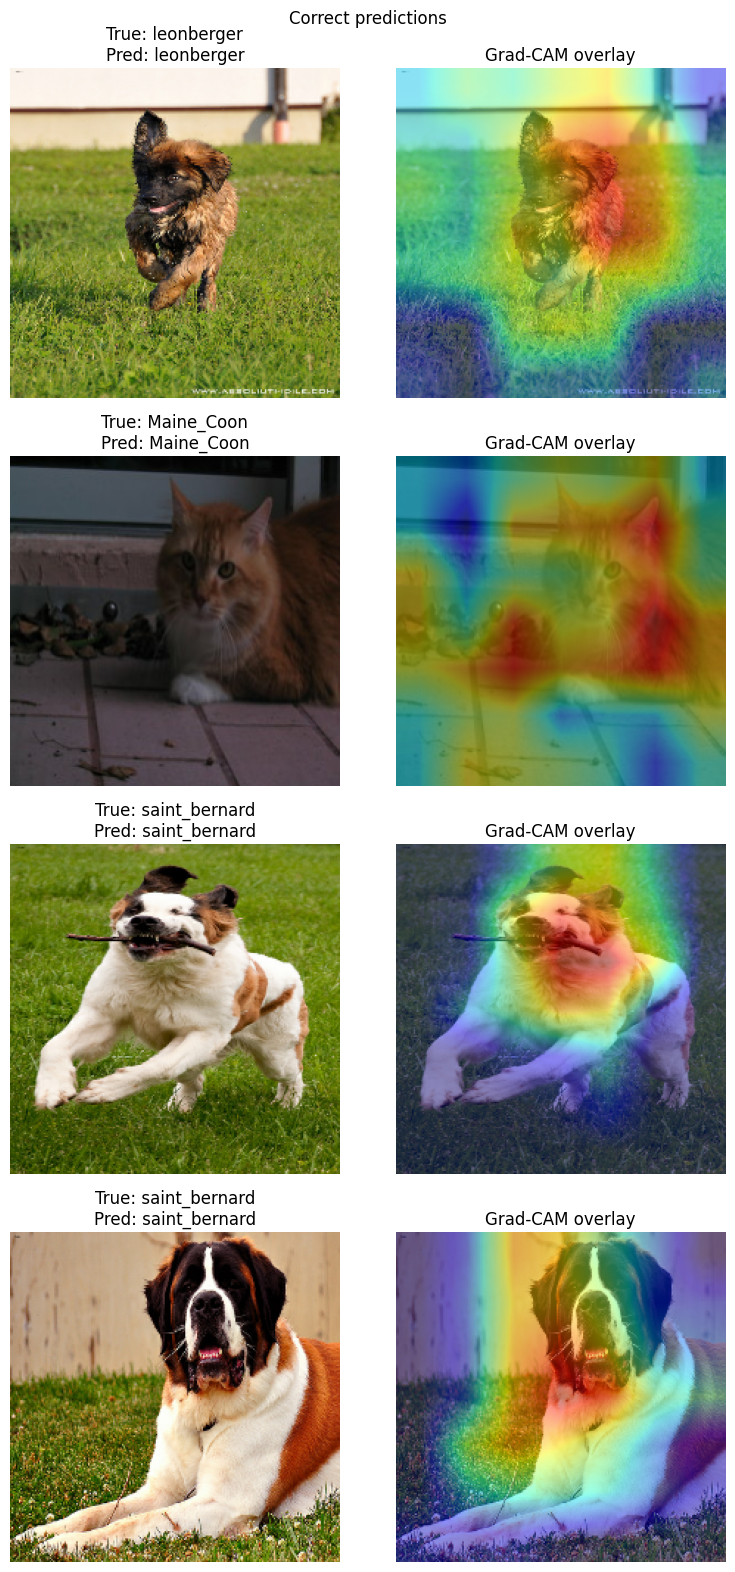

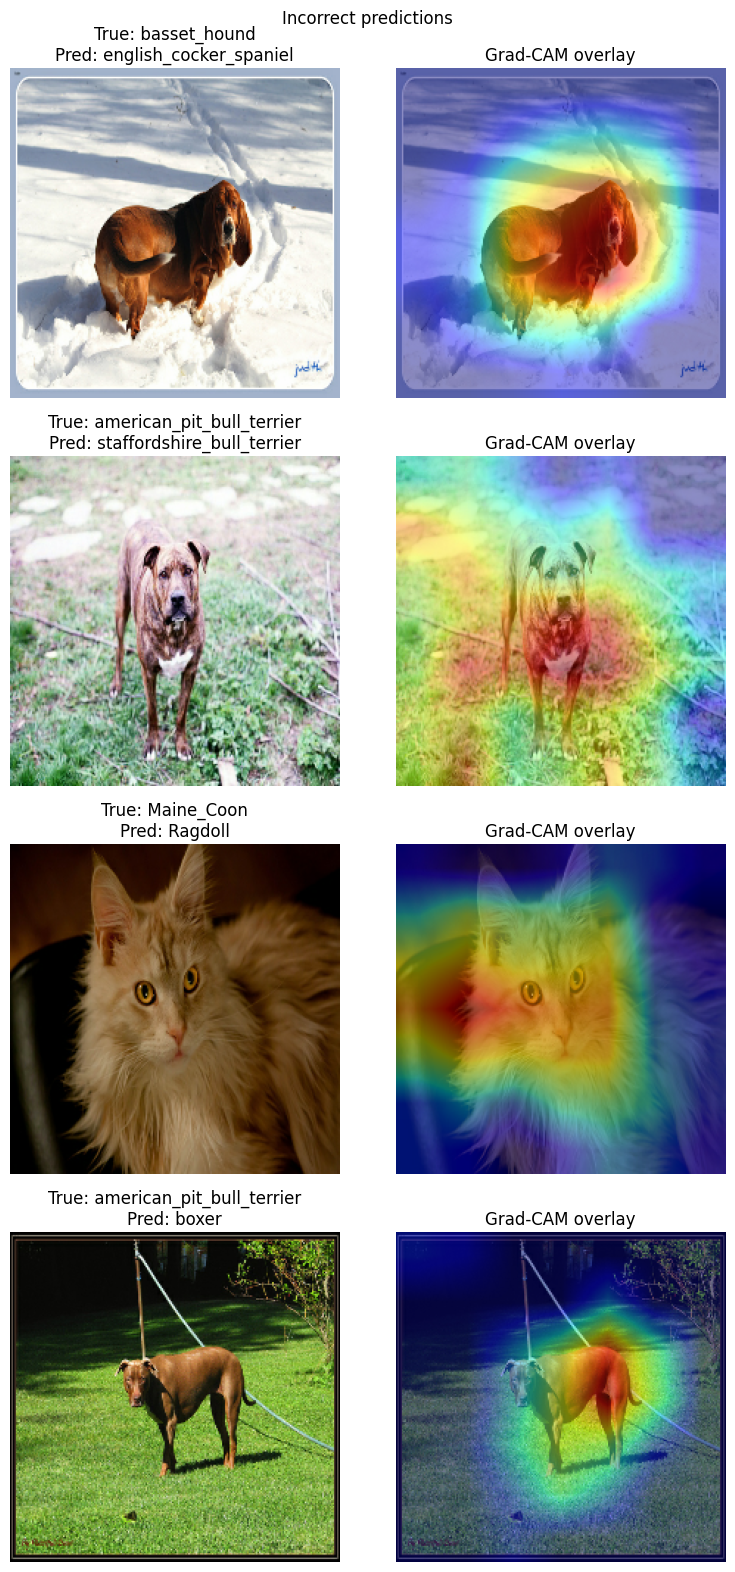

In [6]:
def denormalize_mobilenet(image):
    return np.clip((image + 1.0) / 2.0, 0, 1)

def save_gradcam_grid(selected, output_path, title):
    if not selected:
        print(f"No examples available for {title}")
        return
    fig, axes = plt.subplots(len(selected), 2, figsize=(8, 4 * len(selected)))
    if len(selected) == 1:
        axes = np.array([axes])
    for row, ex in enumerate(selected):
        image_batch = ex["image"][np.newaxis, ...]
        heatmap = make_nested_backbone_gradcam_heatmap(
            image_batch,
            classifier,
            backbone_layer_name="mobilenetv2_1.00_224",
            last_conv_layer_name="Conv_1",
            pred_index=ex["pred"],
        )
        heatmap = tf.image.resize(heatmap[..., np.newaxis], (224, 224)).numpy().squeeze()
        image = denormalize_mobilenet(ex["image"])
        overlay = overlay_heatmap(image, heatmap)
        axes[row, 0].imshow(image)
        axes[row, 0].set_title(f"True: {label_names[ex['label']]}\nPred: {label_names[ex['pred']]}")
        axes[row, 1].imshow(overlay)
        axes[row, 1].set_title("Grad-CAM overlay")
        for col in range(2):
            axes[row, col].axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    fig.savefig(output_path, dpi=160)
    plt.show()

save_gradcam_grid(correct, PROJECT_ROOT / "results/gradcam/correct_predictions_gradcam.png", "Correct predictions")
save_gradcam_grid(incorrect, PROJECT_ROOT / "results/gradcam/incorrect_predictions_gradcam.png", "Incorrect predictions")

## Interpretation of Incorrect Predictions

The Grad-CAM visualizations show that the model is usually focusing on the animal rather than completely irrelevant image regions, which means the classifier has learned meaningful pet-related visual features. However, several mistakes happen because the highlighted regions correspond to features that are shared between visually similar breeds.

In the first example, the true class is `basset_hound`, but the model predicts `english_cocker_spaniel`. The heatmap focuses strongly on the dog’s head, ears, and upper body. This mistake is understandable because both breeds can have long ears and similar brown fur patterns.

In the second example, the true class is `american_pit_bull_terrier`, but the model predicts `staffordshire_bull_terrier`. The model focuses mainly on the dog’s face and chest area. These two breeds are visually very similar, so this is a reasonable confusion rather than a completely random error.

In the third example, the true class is `Maine_Coon`, but the model predicts `Ragdoll`. The heatmap focuses on the cat’s face and fur around the head. This suggests the model is using relevant features, but it may confuse long-haired cat breeds because both classes have fluffy fur and similar facial structures.

In the fourth example, the true class is `american_pit_bull_terrier`, but the model predicts `boxer`. The heatmap focuses mostly on the dog’s body instead of the face. This may explain the wrong prediction, because body shape and color alone are not always enough to distinguish between similar dog breeds.

Overall, the incorrect predictions are mostly caused by **fine-grained breed similarity**, not because the model completely fails to detect the animal. In most cases, the Grad-CAM activation is located on the pet, especially the face, ears, chest, and body. However, some heatmaps also include background regions, which may indicate that the classifier sometimes relies on contextual or non-discriminative features.